In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("02-2025.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,70517388180,2025-02-01 09:55,Inbound,00:00:00,NaN,NaN
1,70518185887,2025-02-01 10:02,Outbound,00:00:18,NaN,Sam Steindorf
2,70517655923,2025-02-01 10:02,Inbound,00:00:00,NaN,NaN
3,70519880054,2025-02-01 10:03,Outbound,00:28:57,NaN,Sam Steindorf
4,70523503961,2025-02-01 10:08,Outbound,00:29:01,NaN,David Valdez


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9390 entries, 0 to 9389
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             9390 non-null   int64  
 1   Activity date         9390 non-null   str    
 2   Call direction        8406 non-null   str    
 3   Call duration         8681 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  9038 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 829.9 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 9390 entries, 0 to 9389
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         9390 non-null   str  
 1   Call direction        8406 non-null   str  
 2   Call duration         8681 non-null   str  
 3   Activity assigned to  9038 non-null   str  
dtypes: str(4)
memory usage: 683.2 KB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors='coerce'
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 9390 entries, 0 to 9389
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         9390 non-null   datetime64[us]
 1   Call direction        8406 non-null   str           
 2   Call duration         8681 non-null   str           
 3   Activity assigned to  9038 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 536.5 KB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-02-01 09:55:00,Inbound,00:00:00,NaN,2025-02-01
1,2025-02-01 10:02:00,Outbound,00:00:18,Sam Steindorf,2025-02-01
2,2025-02-01 10:02:00,Inbound,00:00:00,NaN,2025-02-01
3,2025-02-01 10:03:00,Outbound,00:28:57,Sam Steindorf,2025-02-01
4,2025-02-01 10:08:00,Outbound,00:29:01,David Valdez,2025-02-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [26]:
daily_calls.head()

,date,call_count
0,2025-02-01,32
1,2025-02-02,14
2,2025-02-03,428
3,2025-02-04,461
4,2025-02-05,490


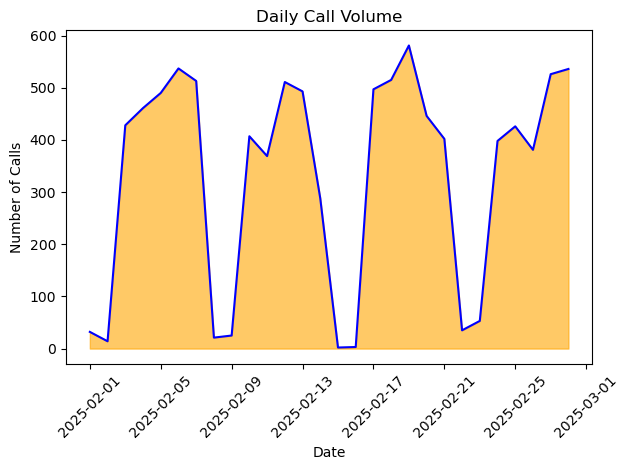

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title('Daily Call Volume')
plt.xlabel('Date')
plt.ylabel('Number of Calls')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-02-01 09:55:00,Inbound,00:00:00,NaN,Saturday
1,2025-02-01 10:02:00,Outbound,00:00:18,Sam Steindorf,Saturday
2,2025-02-01 10:02:00,Inbound,00:00:00,NaN,Saturday
3,2025-02-01 10:03:00,Outbound,00:28:57,Sam Steindorf,Saturday
4,2025-02-01 10:08:00,Outbound,00:29:01,David Valdez,Saturday


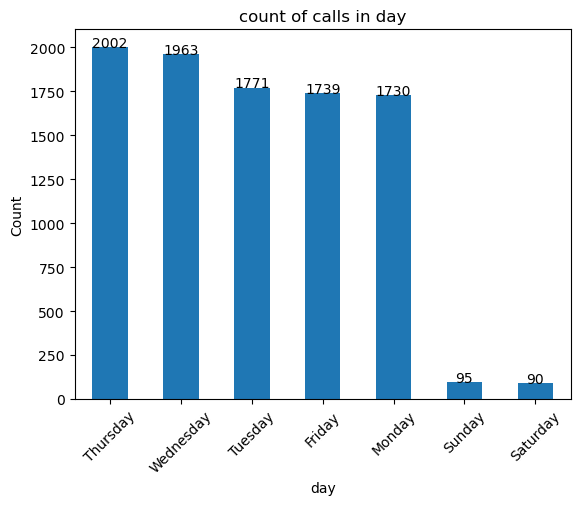

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

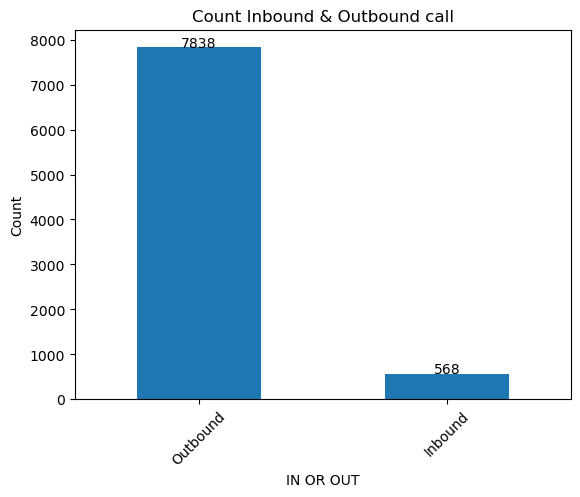

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

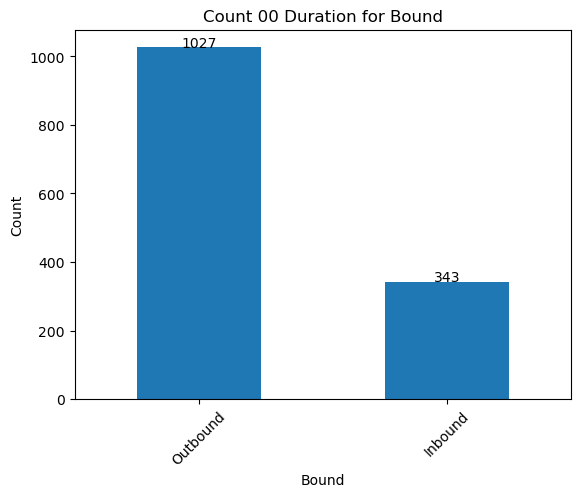

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
276,2025-02-03 16:07:00,Outbound,NaN,Christian Banks,Monday
628,2025-02-04 14:45:00,Inbound,NaN,Christian Banks,Tuesday
630,2025-02-04 14:50:00,Outbound,NaN,Christian Banks,Tuesday
1095,2025-02-05 15:39:00,Outbound,NaN,Christian Banks,Wednesday
1108,2025-02-05 15:58:00,Outbound,NaN,Christian Banks,Wednesday
1119,2025-02-05 16:03:00,Outbound,NaN,Christian Banks,Wednesday
1123,2025-02-05 16:06:00,Outbound,NaN,Christian Banks,Wednesday
2145,2025-02-07 14:00:00,Outbound,NaN,Christian Banks,Friday
2704,2025-02-10 15:49:00,Outbound,NaN,Christian Banks,Monday
2934,2025-02-11 09:17:00,Inbound,NaN,Robin Stoehr,Tuesday


In [48]:
df4 = df1.copy()

In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

1370

In [54]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 9390 entries, 0 to 9389
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         9390 non-null   datetime64[us]
 1   Call direction        8406 non-null   str           
 2   Call duration         8681 non-null   float64       
 3   Activity assigned to  9038 non-null   str           
 4   day                   9390 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 607.5 KB


In [56]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [58]:
df4 = df4.dropna(subset = ['Call direction'])

In [60]:
(df4['Call duration'] == 0).sum()

1426

In [62]:
df4.info()

<class 'pandas.DataFrame'>
Index: 8406 entries, 0 to 9389
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         8406 non-null   datetime64[us]
 1   Call direction        8406 non-null   str           
 2   Call duration         8406 non-null   float64       
 3   Activity assigned to  8065 non-null   str           
 4   day                   8406 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 616.4 KB


# Working Call Assigner

In [65]:
df1['Activity assigned to'].nunique()

25

In [67]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[                nan,     'Sam Steindorf',      'David Valdez',
     'Oliver Martin',        'Tyler Jury',    'Boston Hoppman',
   'Christian Banks',      'Robin Stoehr',    'Cameron Dudley',
      'Karen Parker',     'Garrett Evans',       'Tyler Smith',
     'Keith Antonio',    'David Banister',       'Paol Guzman',
         'Terry Kim',   'Spenser Szakacs',  'Chrystel Manabat',
    'Nick Rothacher',   'Adonis Baybayan',         'Juan Calo',
      'Bill Goodwin',   'Blake Roudebush',       'Kevin Nuesi',
 'Brittany Digiulio',          'June Kim']
Length: 26, dtype: str

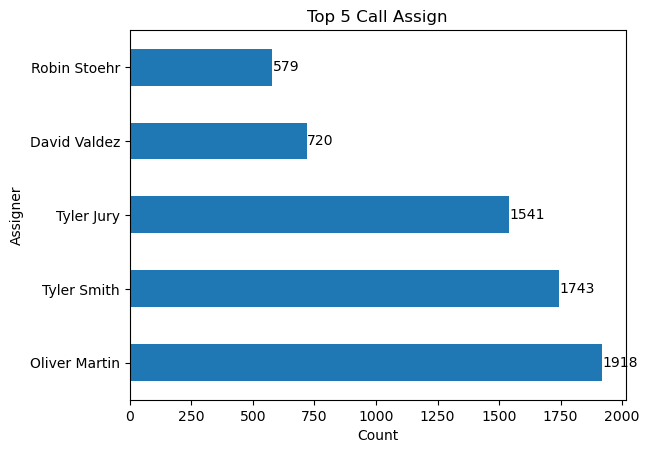

In [69]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [72]:
df4['Call duration'].max()

54.36666666666667

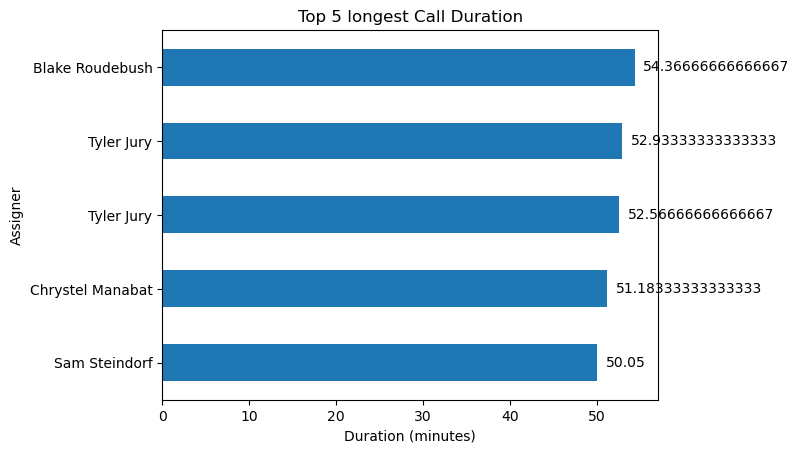

In [74]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [77]:
df3 = df1.copy()

In [79]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [81]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [83]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

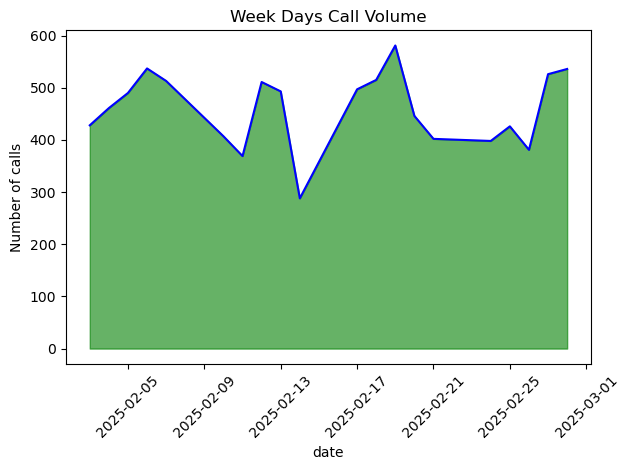

In [85]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [88]:
df5=df4.copy()

In [90]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [92]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-02-01 09:55:00,Inbound,0.000000,NaN,Saturday
1,2025-02-01 10:02:00,Outbound,0.300000,Sam Steindorf,Saturday
2,2025-02-01 10:02:00,Inbound,0.000000,NaN,Saturday
3,2025-02-01 10:03:00,Outbound,28.950000,Sam Steindorf,Saturday
4,2025-02-01 10:08:00,Outbound,29.016667,David Valdez,Saturday


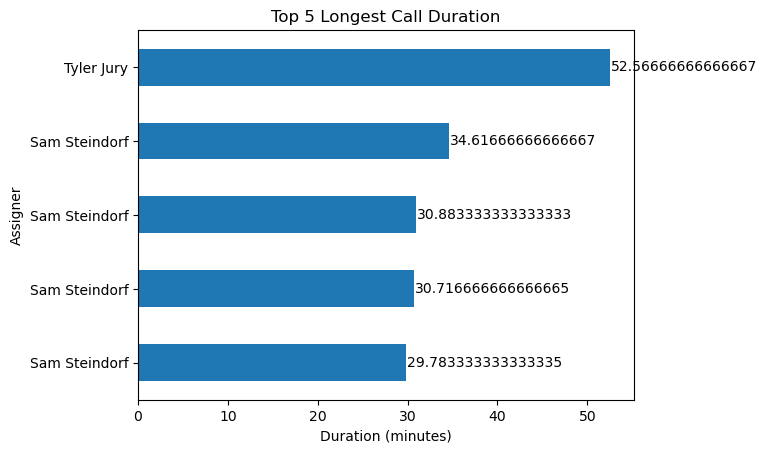

In [94]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner 

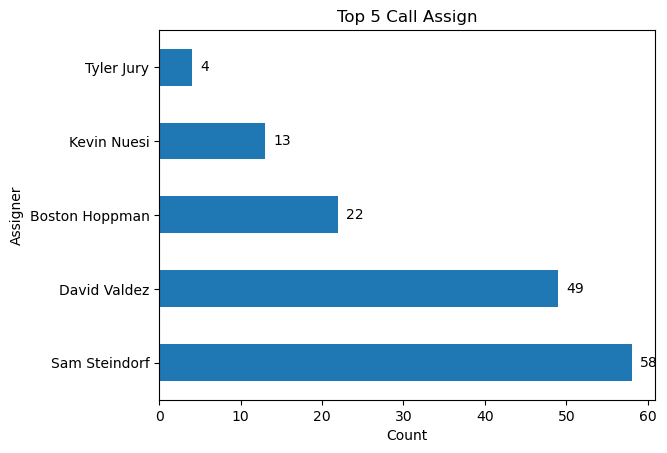

In [97]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [100]:
df4["Call duration"].mean()

1.8867852327702435

In [102]:
df4["Call duration"].median()

0.11666666666666667

# Without Call Assigner Calls

In [105]:
df6 = df3.copy()

In [107]:
df6['month'] = df6['Activity date'].dt.month_name()

In [109]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

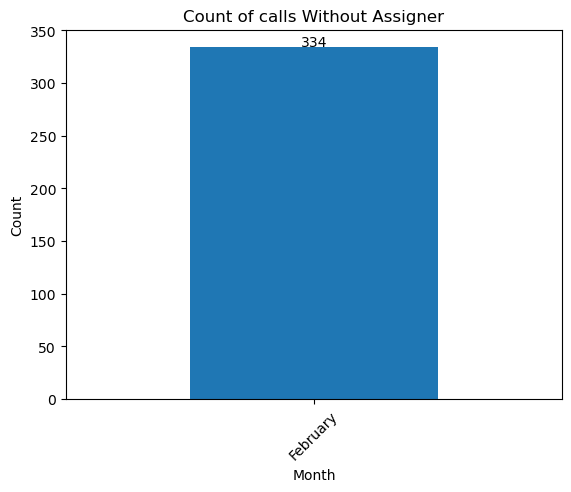

In [111]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [114]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [116]:
top5 = daily_calls.sort_values(ascending=False).head(5)

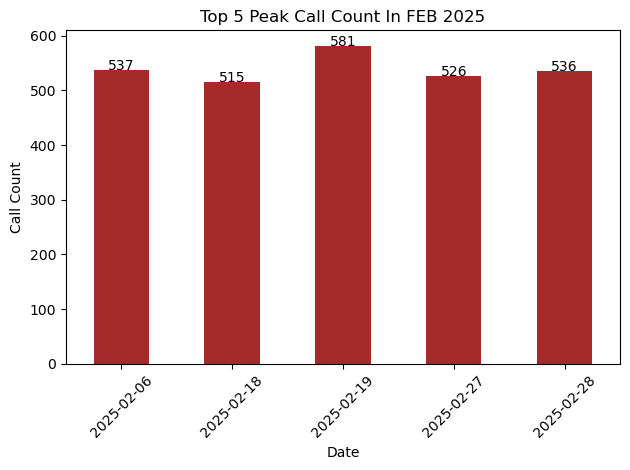

In [120]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In FEB 2025")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()